# Lab 8 — Capacity, Block Codes, CRCs and Convolutional Codes

**Companion to Chapter 14** (*Classical Codes*), with the capacity section tied to
**Chapter 13** (*Information Theory*).
**Time needed:** about 75 minutes. **Difficulty:** core.

Shannon told us in 1948 how far we are from perfection; the classical codes of the following
three decades were the first serious attempts to close the gap. In this lab you will measure
that gap, then close part of it with a Hamming code, a K = 7 convolutional code decoded by
Viterbi's algorithm (the code on Voyager, 802.11a/g and DVB-S), and see why every frame also
carries a CRC and why codes need interleavers when errors come in bursts.

### What you will learn
1. Compute Shannon capacity, the Shannon limit and constellation-constrained capacity.
2. Decode Hamming (7,4) by syndromes and measure its (modest) coding gain.
3. Use a CRC for error *detection* and understand what it guarantees.
4. Measure the gain of the K = 7 (133,171) convolutional code with hard and soft Viterbi decoding.
5. Raise the code rate by puncturing, and defeat burst errors with interleaving.

### Prerequisites
Lab 2 (BER, LLRs). Binary arithmetic mod 2. Chapters 13–14.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | Capacity and the Shannon limit | |
| 2 | Hamming (7,4) | |
| 3 | CRCs: error detection | |
| 4 | Convolutional codes and Viterbi decoding | |
| 5 | Puncturing | |
| 6 | Interleaving against burst errors | |
| 7 | Watching the decoder work | yes |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp
import commlib as cl
from commlib import labkit as lk

rng = lk.setup(seed=8, lab="08")

def bpsk_awgn(c_bits, ebn0_db, rate):
    """BPSK over AWGN at a given Eb/N0 for a code of the given rate. Returns (y, sigma)."""
    sigma = np.sqrt(1 / (2 * rate * 10 ** (ebn0_db / 10)))
    y = (1 - 2 * c_bits.astype(float)) + sigma * rng.standard_normal(len(c_bits))
    return y, sigma

Lab 08 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 8


## 1. Capacity and the Shannon limit

For the band-limited AWGN channel, $C = \log_2(1 + \mathrm{SNR})$ bits/s/Hz. Writing the SNR in
terms of the spectral efficiency $\eta$ gives the condition for reliable communication,

$$\frac{E_b}{N_0} \ge \frac{2^\eta - 1}{\eta}\ \xrightarrow{\ \eta\to 0\ }\ \ln 2 = -1.59\ \mathrm{dB}.$$

Real constellations cannot reach the Gaussian-input curve. Their **constrained capacity**
(mutual information with equiprobable points) is estimated by Monte Carlo:
$I = k - E\big[\log_2 \sum_a e^{-(|y-a|^2-|y-x|^2)/N_0}\big]$.

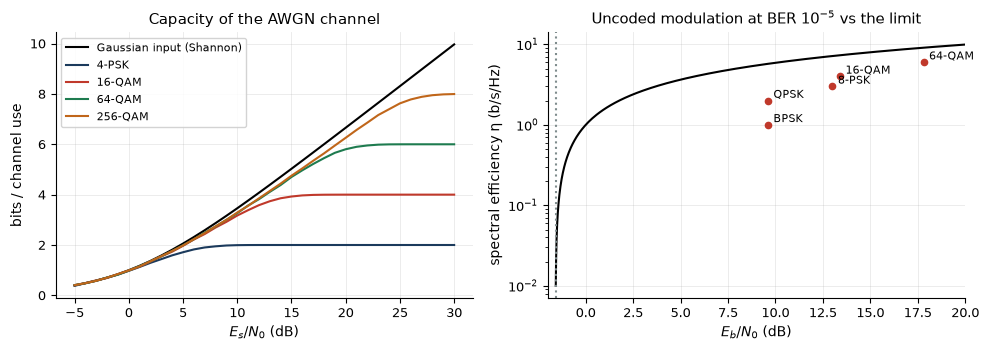

In [3]:
def constrained_capacity(c, esn0_db, n=20000):
    idx = rng.integers(0, c.M, n)
    x = c.points[idx]
    y, n0 = cl.awgn_esn0(x, esn0_db, rng=rng, es=1.0)
    d = -np.abs(y[:, None] - c.points[None, :]) ** 2 / n0
    return c.k - np.mean((logsumexp(d, axis=1) - d[np.arange(n), idx]) / np.log(2))

snr = np.arange(-5, 31, 1.0)
f, ax = lk.fig("row2", 1, 2)
ax[0].plot(snr, np.log2(1 + lk.undb(snr)), "k", label="Gaussian input (Shannon)")
for nm in ["qpsk", "16qam", "64qam", "256qam"]:
    c = cl.get_constellation(nm)
    ax[0].plot(snr, [constrained_capacity(c, s_) for s_ in snr], label=c.name)
ax[0].set_xlabel("$E_s/N_0$ (dB)"); ax[0].set_ylabel("bits / channel use"); ax[0].legend(fontsize=8)
ax[0].set_title("Capacity of the AWGN channel")
eta = np.logspace(-2, 1, 200)
ax[1].semilogy(lk.db((2 ** eta - 1) / eta), eta, "k", label="Shannon bound")
ax[1].axvline(-1.59, color=lk.GRAY, ls=":")
pts = {"BPSK": (9.6, 1), "QPSK": (9.6, 2), "8-PSK": (13.0, 3), "16-QAM": (13.4, 4), "64-QAM": (17.8, 6)}
for nm, (e, k) in pts.items():
    ax[1].plot(e, k, "o", color=lk.RED)
    ax[1].annotate(nm, (e, k), xytext=(4, 2), textcoords="offset points", fontsize=8)
ax[1].set_xlabel("$E_b/N_0$ (dB)"); ax[1].set_ylabel("spectral efficiency η (b/s/Hz)")
ax[1].set_title("Uncoded modulation at BER $10^{-5}$ vs the limit"); ax[1].set_xlim(-2, 20)
lk.show(f)

**What you should see.** Each constellation's capacity saturates at $k$ bits; below saturation
they hug the Shannon curve. The horizontal gap between each uncoded dot and the bound (about
9–11 dB) is the coding gain on offer. Chapters 14 and 15 are about spending complexity to claim it.

### Try it yourself 1.1
What is the minimum $E_b/N_0$ (dB) for reliable communication at $\eta = 2$ b/s/Hz?

In [5]:
answer_1_1 = None
lk.check("1.1 Shannon limit at 2 b/s/Hz", answer_1_1, lk.db((2 ** 2 - 1) / 2), atol=0.02)

[TODO] 1.1 Shannon limit at 2 b/s/Hz: not attempted yet: replace the None with your answer

## 2. Hamming (7,4)

Four data bits, three parity bits, $d_{\min} = 3$: any single error per block is corrected.
The **syndrome** $\mathbf{s} = \mathbf{H}\mathbf{r}^T$ equals the column of $\mathbf{H}$ at the error
position, so decoding is a table look-up. Compare at *equal* $E_b/N_0$: coded bits get only
$E_c = R E_b$, so each coded bit is noisier and the code must earn back that $10\log_{10}(7/4) = 2.4$ dB.

In [7]:
eb = np.arange(0, 11, 1.0)
u = cl.random_bits(4 * 50000, rng)
ber_h = []
for e in eb:
    y, _ = bpsk_awgn(cl.hamming74_encode(u), e, 4 / 7)
    ber_h.append(np.mean(cl.hamming74_decode((y < 0).astype(np.int8)) != u))
# demonstration of the syndrome
cw = cl.hamming74_encode(np.array([1, 0, 1, 1]))
r = cw.copy(); r[5] ^= 1
lk.table([["codeword", "".join(map(str, cw))], ["received (bit 5 flipped)", "".join(map(str, r))],
          ["syndrome H r^T", "".join(map(str, (cl.coding._H74 @ r) % 2))],
          ["column 5 of H", "".join(map(str, cl.coding._H74[:, 5]))],
          ["decoded data", "".join(map(str, cl.hamming74_decode(r)))]], ["", "bits"])

,bits
codeword,1011010
received (bit 5 flipped),1011000
syndrome H r^T,010
column 5 of H,010
decoded data,1011


## 3. CRCs: error detection

A cyclic redundancy check appends the remainder of the message polynomial (times $D^r$)
divided by a generator $g(D)$ of degree $r$. The receiver recomputes it. A CRC of degree $r$
detects **every** burst of length $\le r$, and misses a random error pattern with probability
about $2^{-r}$. We test NR's CRC-11 (TS 38.212) on 10,000 corrupted 100-bit messages each.

In [9]:
def crc_ok(msg_and_crc, poly):
    r_ = len(poly) - 1
    return np.array_equal(cl.crc_remainder(msg_and_crc[:-r_], poly), msg_and_crc[-r_:])

poly = cl.CRC11_5G
msg = cl.random_bits(100, rng)
frame = np.concatenate([msg, cl.crc_remainder(msg, poly)])
rows = []
for kind in ["single bit", "burst ≤ 11", "burst of 12", "random (p = 0.1)"]:
    missed = 0
    trials = 10000
    for _ in range(trials):
        e = np.zeros(len(frame), dtype=np.int8)
        if kind == "single bit":
            e[rng.integers(len(frame))] = 1
        elif kind.startswith("burst"):
            L = rng.integers(2, 12) if "≤" in kind else 12
            st = rng.integers(0, len(frame) - L)
            e[st] = e[st + L - 1] = 1
            e[st + 1:st + L - 1] = rng.integers(0, 2, L - 2)
        else:
            e = (rng.random(len(frame)) < 0.1).astype(np.int8)
        missed += crc_ok(frame ^ e, poly)
    rows.append([kind, missed, missed / trials])
lk.table(rows, ["error pattern", "undetected (of 10,000)", "rate"], fmt={2: ".1e"},
         title=f"CRC-11 on 100-bit messages (2^-11 = {2 ** -11:.1e})")

error pattern,"undetected (of 10,000)",rate
single bit,0,0.0e+00
burst ≤ 11,0,0.0e+00
burst of 12,9,9.0e-04
random (p = 0.1),6,6.0e-04


**What you should see.** Zero misses for single errors and all bursts up to 11 bits. Random
patterns are missed at about $2^{-11} \approx 5\times 10^{-4}$, and bursts of exactly 12 bits at
about $2^{-10}$ (theory for bursts of length $r+1$ is $2^{-(r-1)}$). That is
why the CRC is the arbiter of HARQ ACK/NACK and why a list decoder (Lab 9) can use it to pick a candidate.

## 4. Convolutional codes and the Viterbi algorithm

The K = 7, rate-1/2 code with generators $(133, 171)_8$ has free distance $d_{\text{free}} = 10$.
Viterbi decoding finds the maximum-likelihood path through its 64-state trellis. Feeding the
decoder soft LLRs instead of hard bits gains about 2 dB, a lesson that carries over to every
modern decoder.

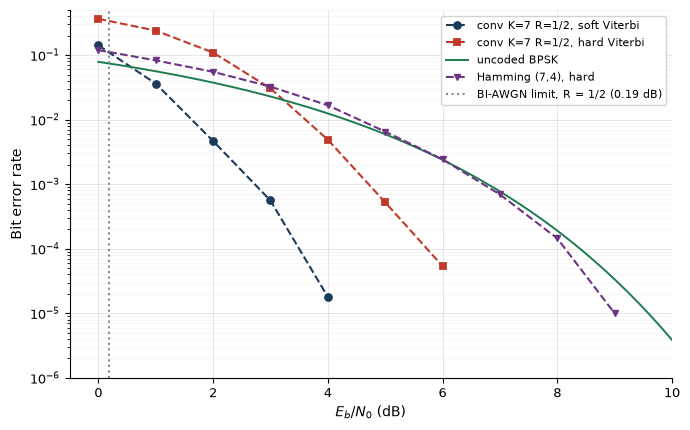

In [12]:
cc = cl.ConvCode()

def ber_conv(e, soft=True, n=1000, batch=100, min_errors=100, max_bits=500_000):
    """Monte Carlo BER, `batch` frames of n bits at a time (vectorised Viterbi)."""
    def trial(_):
        u_ = rng.integers(0, 2, (batch, n))
        c = cc.encode_batch(u_)
        sigma = np.sqrt(1 / (2 * cc.rate * 10 ** (e / 10)))
        y = (1 - 2.0 * c) + sigma * rng.standard_normal(c.shape)
        uh = cc.decode_batch(2 * y / sigma ** 2 if soft else np.sign(y))
        return np.sum(uh != u_), u_.size
    return lk.ber_mc(trial, min_errors, max_bits)

eb2 = np.arange(0, 7.5, 1.0)
ber_soft = [ber_conv(e, True) for e in np.arange(0, 5, 1.0)]
ber_hard = [ber_conv(e, False) for e in eb2]
ber_soft += [0.0] * (len(eb2) - len(ber_soft))   # below 1e-6: not simulated
ebf = np.linspace(0, 10, 200)
f, ax = lk.fig("ber")
lk.ber_plot(ax, eb2, {"conv K=7 R=1/2, soft Viterbi": ber_soft, "conv K=7 R=1/2, hard Viterbi": ber_hard},
            {"uncoded BPSK": cl.ber_bpsk(ebf)}, x_theory=ebf, legend=False)
ax.plot(eb, np.where(np.array(ber_h) > 0, ber_h, np.nan), "v--", color=lk.PURPLE, label="Hamming (7,4), hard")
ax.axvline(0.19, color=lk.GRAY, ls=":", label="BI-AWGN limit, R = 1/2 (0.19 dB)")
ax.legend(fontsize=8); ax.set_xlim(-0.5, 10)
lk.show(f)

**What you should see.** Hamming (7,4) gains only about 0.5–1 dB at $10^{-5}$. The convolutional
code with hard decisions gains roughly 3 dB, with soft decisions about 5 dB (4.4 dB at $10^{-5}$
in the literature). Even so, the soft Viterbi curve is still about 4 dB from the 0.19 dB limit:
the gap that turbo, LDPC and polar codes (Lab 9) close.

### Try it yourself 4.1
The asymptotic coding gain of a code with rate $R$ and free distance $d$ with soft decisions is
$10\log_{10}(R\,d)$ dB. What is it for this code?

In [14]:
answer_4_1 = None
lk.check("4.1 asymptotic coding gain of (133,171)", answer_4_1, lk.db(0.5 * 10), atol=0.05)

[TODO] 4.1 asymptotic coding gain of (133,171): not attempted yet: replace the None with your answer

## 5. Puncturing

Deleting coded bits in a fixed pattern raises the rate without a new decoder: the Viterbi
decoder treats deleted positions as erasures (LLR = 0). 802.11a obtains rate 3/4 from the
rate-1/2 mother code by keeping 4 of every 6 coded bits.

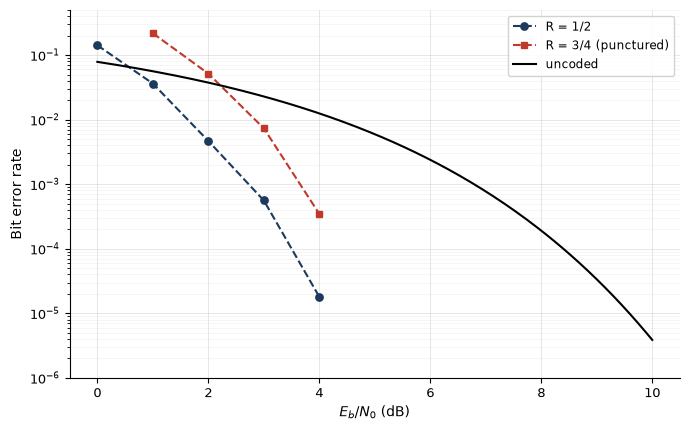

In [16]:
PAT34 = np.array([1, 1, 1, 0, 0, 1], dtype=bool)   # keep mask over (A1 B1 A2 B2 A3 B3)

def puncture(c, pat):
    m = np.tile(pat, int(np.ceil(len(c) / len(pat))))[:len(c)]
    return c[m], m

def depuncture(llr, m):
    out = np.zeros(len(m)); out[m] = llr
    return out

def ber_punct(e, n=999, batch=100, min_errors=100, max_bits=500_000):
    m = np.tile(PAT34, int(np.ceil(2 * (n + 6) / 6)))[:2 * (n + 6)]
    def trial(_):
        u_ = rng.integers(0, 2, (batch, n))
        cbits = cc.encode_batch(u_)[:, m]
        sigma = np.sqrt(1 / (2 * 0.75 * 10 ** (e / 10)))
        y = (1 - 2.0 * cbits) + sigma * rng.standard_normal(cbits.shape)
        llr = np.zeros((batch, len(m))); llr[:, m] = 2 * y / sigma ** 2
        return np.sum(cc.decode_batch(llr) != u_), u_.size
    return lk.ber_mc(trial, min_errors, max_bits)

eb3 = np.arange(1, 7.5, 1.0)
f, ax = lk.fig("ber")
lk.ber_plot(ax, eb2, {"R = 1/2": ber_soft}, legend=False)
ax.plot(eb3, np.where(np.array(bp := [ber_punct(e) for e in eb3]) > 0, bp, np.nan), "s--", color=lk.RED,
        label="R = 3/4 (punctured)")
ax.plot(ebf, cl.ber_bpsk(ebf), "k", label="uncoded"); ax.legend()
lk.show(f)

**What you should see.** Rate 3/4 costs roughly 1–1.5 dB relative to rate 1/2 but still beats uncoded
BPSK by several dB, while carrying 50% more data per channel use.

## 6. Interleaving against burst errors

The Viterbi decoder expects independent errors; a fade (Lab 5) delivers them in bursts that
overwhelm the free distance. A **block interleaver** writes coded bits into a matrix by rows
and reads them out by columns, so a burst of $B$ channel errors is spread $D$ positions apart
after de-interleaving. We model a bursty channel with a two-state **Gilbert–Elliott** chain:
a "good" state (BSC with $p = 0.001$) and a "bad" state ($p = 0.3$) with mean bad-burst length 20.

In [19]:
def gilbert_elliott(n, p_gb=0.005, p_bg=0.05, pg=0.001, pb=0.3):
    state = np.zeros(n, dtype=bool)
    s = False
    u_ = rng.random(n)
    for i in range(n):
        s = (u_[i] < p_gb) if not s else (u_[i] >= p_bg)
        state[i] = s
    return rng.random(n) < np.where(state, pb, pg)

def interleave(x, spread):
    """Block interleaver: write row by row into a matrix with `spread` columns, read column
    by column. Adjacent channel bits then come from coded bits `spread` positions apart."""
    return x.reshape(-1, spread).T.ravel()

def deinterleave(x, spread):
    return x.reshape(spread, -1).T.ravel()

n_info = 2042                      # coded length 2*(2042+6) = 4096, divisible by all spreads
rows = []
for D in [1, 4, 16, 64]:
    errs = tot = 0
    for _ in range(30):
        u_ = cl.random_bits(n_info, rng)
        c = cc.encode(u_)
        rx = deinterleave(interleave(c, D) ^ gilbert_elliott(len(c)), D)
        errs += np.sum(cc.decode(1 - 2.0 * rx) != u_); tot += n_info
    rows.append([D, errs / tot])
lk.table(rows, ["interleaver spread D", "decoded BER"], fmt={1: ".2e"},
         title="Hard-decision Viterbi over a Gilbert–Elliott burst channel (raw BER about 3%)")

interleaver spread D,decoded BER
1,2.37e-02
4,1.24e-02
16,2.94e-04
64,1.63e-04


**What you should see.** Without interleaving (D = 1) the decoder barely helps against a 3% raw
error rate; as the spread grows beyond the code's constraint length and toward the burst length,
each burst is scattered into isolated errors and the decoded BER drops by an order of magnitude
or more.
The price is latency: the whole matrix must arrive before decoding starts. GSM, DVB-T and 802.11
all interleave; NR relies on LDPC codes spanning whole transport blocks plus OFDM frequency spreading.

## 7. Watching the decoder work

Top: which coded bits arrived with the wrong sign. Bottom: residual errors after Viterbi decoding.

### Interactive

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

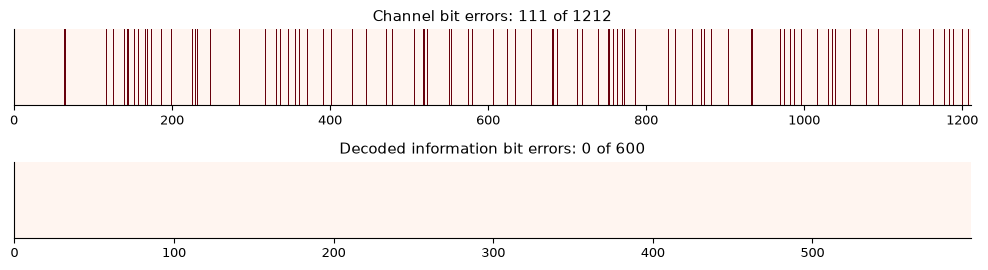

In [22]:
def frame_view(ebn0_db=2.0, decisions="soft"):
    u_ = cl.random_bits(600, rng)
    c = cc.encode(u_)
    y, sigma = bpsk_awgn(c, ebn0_db, 0.5)
    raw = (y < 0) != c
    uh = cc.decode(2 * y / sigma ** 2 if decisions == "soft" else np.sign(y))
    f, ax = lk.fig((10, 2.8), 2, 1)
    ax[0].imshow(raw[None, :], aspect="auto", cmap="Reds", interpolation="nearest"); ax[0].set_yticks([])
    ax[0].set_title(f"Channel bit errors: {raw.sum()} of {len(c)}"); ax[0].grid(False)
    ax[1].imshow((uh != u_)[None, :], aspect="auto", cmap="Reds", interpolation="nearest", vmin=0, vmax=1)
    ax[1].set_yticks([]); ax[1].grid(False)
    ax[1].set_title(f"Decoded information bit errors: {(uh != u_).sum()} of {len(u_)}")
    lk.show(f)

lk.interact(frame_view, ebn0_db=lk.slider(2.0, -1, 8, 0.25, "Eb/N0 (dB)"),
            decisions=lk.choice(["soft", "hard"], desc="decisions"))

**What you should see.** Dozens of scattered channel errors, and after decoding either none or a
short *burst*: when the Viterbi decoder errs it takes a wrong detour through the trellis. This
is why a convolutional inner code is paired with a byte-oriented Reed–Solomon outer code in
DVB-S and deep-space links (CCSDS), with an interleaver between them.

## Key takeaways
* The Shannon limit is −1.59 dB as $\eta \to 0$; uncoded systems are 9–11 dB away at $10^{-5}$.
* Block codes correct $\lfloor(d_{\min}-1)/2\rfloor$ errors; syndromes make decoding a look-up.
* CRCs detect all bursts up to their degree and miss about $2^{-r}$ of random patterns.
* The K = 7 convolutional code gains about 5 dB with soft Viterbi decoding; soft decisions are worth ~2 dB.
* Puncturing trades gain for rate with one decoder; interleaving turns bursts into scattered errors.

## Going further (hardware: USRP B200 / GNU Radio)
* `gnuradio/gr05_coded_link.py --sim --snr -3` is a framed BPSK link that uses this very
  `ConvCode` class: compare raw and decoded BER with Section 4. Then run it through the B200 in
  loopback and lower the TX gain until the decoder starts to fail.

## Exercises
1. **(Warm-up)** Derive the Shannon limit $E_b/N_0 \to \ln 2$ as $\eta \to 0$.
2. **(Core)** Find $d_{\text{free}}$ of the (133,171) code by a breadth-first search on the
   trellis, and evaluate the union bound $P_b \lesssim \sum_d \beta_d Q(\sqrt{2dRE_b/N_0})$ using the
   first few distance-spectrum terms.
3. **(Core)** Implement a (15,11) Hamming code and a (255,239) Reed–Solomon code over GF(256)
   (encode + syndrome computation), and verify that RS corrects any 8 byte errors.
4. **(Stretch)** Implement the BCJR (MAP) decoder for a 4-state recursive systematic code and
   build a rate-1/3 parallel concatenated turbo code (the 3G/4G code). See Chapter 15.

In [25]:
lk.summary()

[good] Lab 08 finished in 34.5 s. Self-checks: 0 passed, 0 failed, 2 still to do.